In [22]:
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt

In [23]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [24]:
gdf = gpd.read_file(RAW_DATA_DIR/'geographic/municipalities/00mun.shp')
cri = pd.read_csv(RESULTS_DATA_DIR/"cri.csv")

In [25]:
gdf['CVEGEO'] = gdf['CVEGEO'].astype(str).str.zfill(5)
cri['CVEGEO'] = cri['CVEGEO'].astype(str).str.zfill(5)

In [26]:
cri.columns

Index(['CVEGEO', 'regime', 'regime_label', 'current_state', 'crime_rate_2024',
       'D', 'U', 'pi', 'G', 'TRS', 'SCS', 'PP', 'CRI_raw', 'CRI',
       'CRI_spatial', 'CRI_label'],
      dtype='object')

In [27]:
gdfcri = gdf.merge(cri[['CVEGEO', 'CRI', 'CRI_raw', 'CRI_spatial', 'CRI_label']], on='CVEGEO', how='left')

In [31]:
def heatmap(df, COLUMN=str, TITLE=str):
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    df.plot(
        column=COLUMN,
        cmap='Blues',
        linewidth=0.1,
        edgecolor='grey',
        legend=True,
        legend_kwds={
            'label': COLUMN,
            'orientation': 'horizontal',
            'shrink': 0.6,
            'pad': 0.02
        },
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        ax=ax
    )
    
    ax.set_title(f"{COLUMN} Mexico Heatmap", fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(RESULTS_DATA_DIR/f'maps/{COLUMN}_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

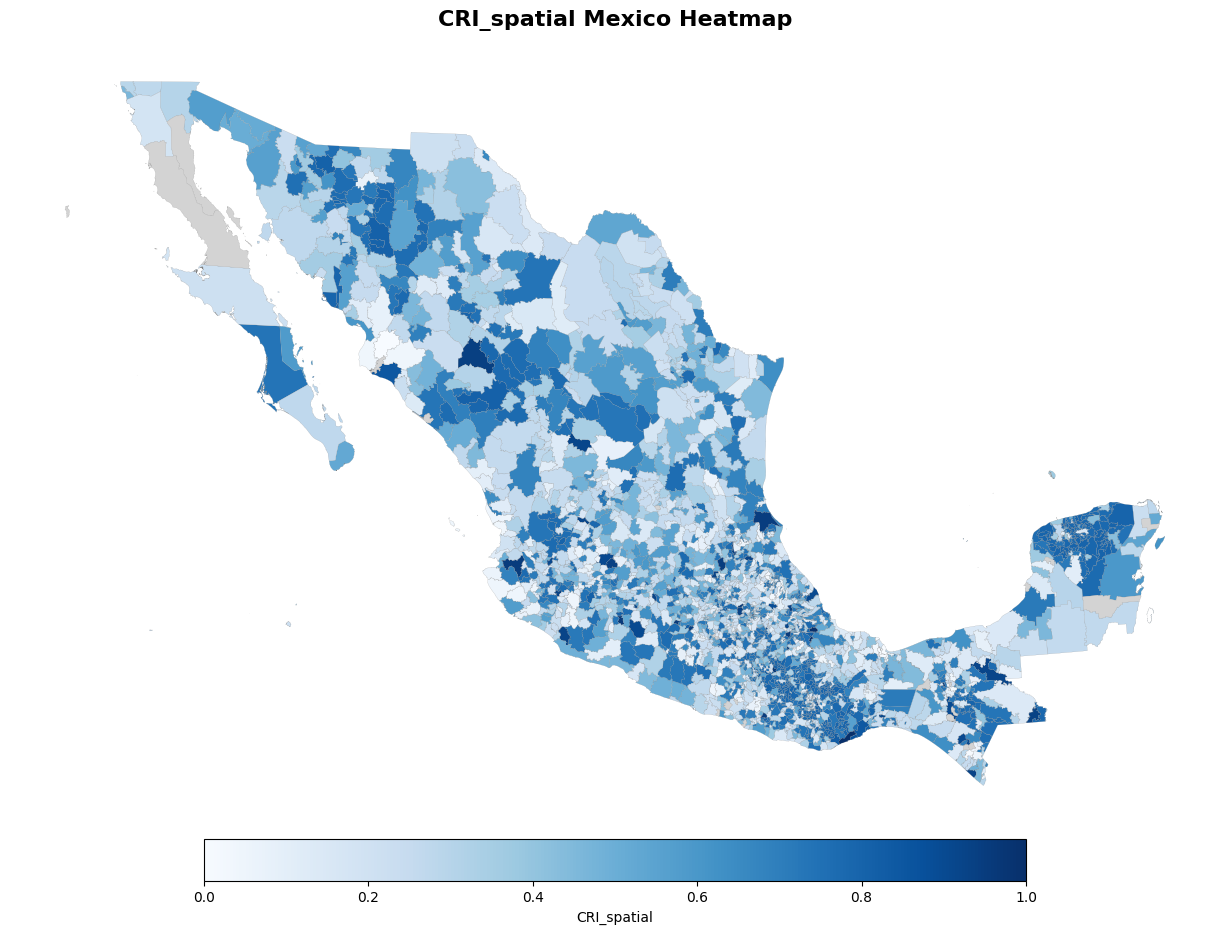

In [32]:
heatmap(gdfcri, 'CRI_spatial', 'CRI Mexico Heatmap')